# 01 â€” Graph Property Measurement

**Purpose:** Measure the structural properties of the Turnbull and newspaper knowledge graphs to determine whether hyperbolic geometry is justified for the KGR model.

**What we need to know:**
1. **Degree distribution** â€” Is it power-law (scale-free)? Power-law â†’ tree-like â†’ hyperbolic helps.
2. **Gromov Î´-hyperbolicity** â€” Direct measure of how tree-like the graph is. Lower Î´ â†’ more tree-like â†’ stronger case for hyperbolic.
3. **Provenance chain depth** â€” How deep do DERIVED_FROM chains go? Deeper â†’ more hierarchical.
4. **Branching factor** â€” Average children per node at each depth level.
5. **Edge type distribution** â€” What proportion of edges are each type?
6. **Connected component structure** â€” One giant component or many small ones?

**Decision rule:** If the graph shows power-law degree distribution AND low Gromov hyperbolicity AND provenance chains deeper than 2-3 hops, hyperbolic geometry is strongly justified. If the graph is dense, flat, and homogeneous, we rethink the geometry.

## Setup

In [1]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from neo4j import GraphDatabase
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Load Neo4j credentials from .env (see .env.example for the expected keys)
load_dotenv()

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")
NEO4J_PASSWORD = os.environ["NEO4J_PASSWORD"]  # required
DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

def run_query(query, params=None):
    with driver.session(database=DATABASE) as session:
        result = session.run(query, params or {})
        return [dict(record) for record in result]

print("Connected to Neo4j.")

Connected to Neo4j.


## 1. Basic Census
How big is the graph? What node and edge types exist?

In [2]:
# Node counts by label
node_counts = run_query("""
    MATCH (n)
    WITH labels(n) AS lbls, count(n) AS cnt
    UNWIND lbls AS label
    RETURN label, sum(cnt) AS count
    ORDER BY count DESC
""")

print("=== NODE TYPES ===")
total_nodes = 0
for row in node_counts:
    print(f"  {row['label']:30s} {row['count']:>10,}")
    total_nodes += row['count']
print(f"  {'TOTAL':30s} {total_nodes:>10,}")

=== NODE TYPES ===
  Mention                           130,205
  Claim                              45,793
  Event                              35,731
  Paragraph                          30,768
  Section                            12,426
  Page                                9,626
  Observation                         9,329
  Measurement                         6,755
  Document                            5,051
  ExtractionRun                       4,997
  Entity                              4,931
  Period                              4,634
  Year                                  117
  Species                                75
  Place                                  64
  Person                                 62
  Concept                                45
  Organization                           34
  Activity                               26
  Habitat                                19
  SurveyMethod                           17
  Refuge                                  1
  TOTAL      

In [3]:
# Edge counts by type
edge_counts = run_query("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(r) AS count
    ORDER BY count DESC
""")

print("=== EDGE TYPES ===")
total_edges = 0
for row in edge_counts:
    print(f"  {row['rel_type']:30s} {row['count']:>10,}")
    total_edges += row['count']
print(f"  {'TOTAL':30s} {total_edges:>10,}")
print(f"\nEdge/Node ratio: {total_edges/total_nodes:.2f}")
print("  (< 2.0 suggests tree-like; > 5.0 suggests dense)")

=== EDGE TYPES ===
  CONTAINS_MENTION                  130,205
  EVIDENCED_BY                       55,122
  PRODUCED                           53,471
  REFERS_TO                          46,509
  HAS_CLAIM                          45,793
  IN_YEAR                            44,925
  OCCURRED_DURING                    37,046
  TRIGGERED                          35,729
  SOURCED_FROM                       35,729
  HAS_PARAGRAPH                      30,768
  DURING                             30,177
  NEXT                               25,717
  POSSIBLY_REFERS_TO                 23,985
  EXPRESSES                          20,283
  HAS_SECTION                        12,468
  HAS_PAGE                            9,626
  SUPPORTS                            9,329
  HAS_MEASUREMENT                     6,755
  PROCESSED_BY                        5,051
  COVERS_YEAR                         5,051
  COVERS_PERIOD                       4,942
  ABOUT_PLACE                         4,942
  LOCATION_FO

## 2. Degree Distribution
The critical question: is this a power-law (scale-free) network?

Power-law degree distributions are a strong signal of hierarchical structure â€” a few hub nodes with many connections, many leaf nodes with few. This is exactly the topology that hyperbolic space represents efficiently.

In [4]:
# Get degree of every node
degrees_raw = run_query("""
    MATCH (n)
    RETURN id(n) AS node_id, 
           size([(n)-[]-() | 1]) AS degree
""")

degrees = np.array([r['degree'] for r in degrees_raw])

print(f"Nodes measured: {len(degrees):,}")
print(f"Mean degree:    {np.mean(degrees):.2f}")
print(f"Median degree:  {np.median(degrees):.1f}")
print(f"Max degree:     {np.max(degrees):,}")
print(f"Degree 1 nodes: {np.sum(degrees == 1):,} ({100*np.mean(degrees==1):.1f}%)")
print(f"Degree > 100:   {np.sum(degrees > 100):,}")
print(f"\nSkewness: {float(np.mean(((degrees - np.mean(degrees))/np.std(degrees))**3)):.2f}")
print("  (High positive skewness â†’ heavy tail â†’ power-law candidate)")

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=3, column=12, offset=26>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 26, 'line': 3, 'column': 12}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (n)\n    RETURN id(n) AS node_id, \n           size([(n)-[]-() | 1]) AS degree\n'


Nodes measured: 295,774
Mean degree:    4.64
Median degree:  2.0
Max degree:     10,437
Degree 1 nodes: 72,792 (24.6%)
Degree > 100:   306

Skewness: 168.88
  (High positive skewness â†’ heavy tail â†’ power-law candidate)


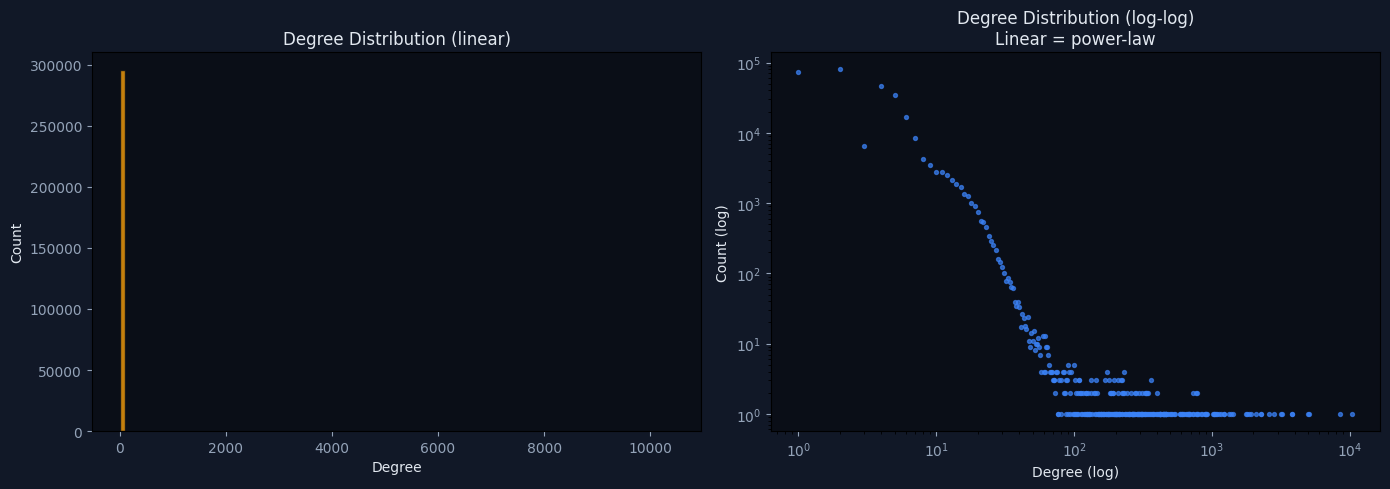

In [5]:
# Plot degree distribution (log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(degrees, bins=100, color='#f59e0b', alpha=0.8, edgecolor='#0a0e17')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution (linear)')
axes[0].set_facecolor('#0a0e17')

# Log-log (power-law test: should be roughly linear)
degree_counts = Counter(degrees)
degs = sorted(degree_counts.keys())
counts = [degree_counts[d] for d in degs]
axes[1].scatter(degs, counts, s=8, color='#3b82f6', alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Count (log)')
axes[1].set_title('Degree Distribution (log-log)\nLinear = power-law')
axes[1].set_facecolor('#0a0e17')

fig.patch.set_facecolor('#111827')
for ax in axes:
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#e2e8f0')
    ax.yaxis.label.set_color('#e2e8f0')
    ax.title.set_color('#e2e8f0')

plt.tight_layout()
plt.show()

In [6]:
# Formal power-law test
try:
    import powerlaw
    fit = powerlaw.Fit(degrees[degrees > 0], discrete=True, verbose=False)
    print(f"Power-law exponent (alpha): {fit.alpha:.3f}")
    print(f"  (typical range for scale-free networks: 2.0 - 3.0)")
    print(f"x_min: {fit.xmin}")
    
    # Compare power-law vs. alternatives
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
    R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal')
    print(f"\nPower-law vs exponential:  R={R_exp:.3f}, p={p_exp:.4f}")
    print(f"Power-law vs lognormal:    R={R_ln:.3f}, p={p_ln:.4f}")
    print("  (R > 0 favors power-law; p < 0.05 is significant)")
except ImportError:
    print("Install 'powerlaw' package for formal power-law test.")
    print("Rough check: if log-log plot is approximately linear, it's power-law.")

Power-law exponent (alpha): 2.864
  (typical range for scale-free networks: 2.0 - 3.0)
x_min: 4.0

Power-law vs exponential:  R=44196.649, p=0.0000
Power-law vs lognormal:    R=5.869, p=0.3076
  (R > 0 favors power-law; p < 0.05 is significant)


## 3. Provenance Chain Depth
How deep do DERIVED_FROM / provenance chains go? This measures the hierarchical depth of the graph.

In [7]:
# Measure provenance chain lengths
# Adjust the relationship type to match your schema
PROVENANCE_REL = "SOURCED_FROM"  # CHANGE if your schema uses a different name

chain_depths = run_query(f"""
    MATCH path = (leaf)-[:{PROVENANCE_REL}*]->(root)
    WHERE NOT (root)-[:{PROVENANCE_REL}]->()
    RETURN length(path) AS depth, count(*) AS num_chains
    ORDER BY depth
""")

print(f"=== PROVENANCE CHAIN DEPTHS ({PROVENANCE_REL}) ===")
if chain_depths:
    for row in chain_depths:
        bar = 'â–ˆ' * min(row['num_chains'] // 10, 50)
        print(f"  Depth {row['depth']:2d}: {row['num_chains']:>8,} chains  {bar}")
    
    max_depth = max(r['depth'] for r in chain_depths)
    total_chains = sum(r['num_chains'] for r in chain_depths)
    avg_depth = sum(r['depth'] * r['num_chains'] for r in chain_depths) / total_chains
    print(f"\n  Max depth:     {max_depth}")
    print(f"  Average depth: {avg_depth:.2f}")
    print(f"  Total chains:  {total_chains:,}")
    print(f"\n  Depth > 2 supports hyperbolic geometry.")
    print(f"  Depth > 4 strongly supports it.")
else:
    print(f"  No {PROVENANCE_REL} chains found. Check relationship type name.")

=== PROVENANCE CHAIN DEPTHS (SOURCED_FROM) ===
  Depth  1:   35,729 chains  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ

  Max depth:     1
  Average depth: 1.00
  Total chains:  35,729

  Depth > 2 supports hyperbolic geometry.
  Depth > 4 strongly supports it.


## 4. Branching Factor by Level
At each depth in the hierarchy, how many children does each node have on average?

In [8]:
# Branching factor: average out-degree for nodes that have the provenance relationship
branching = run_query(f"""
    MATCH (parent)<-[:{PROVENANCE_REL}]-(child)
    WITH parent, count(child) AS num_children
    RETURN 
        avg(num_children) AS avg_branching,
        min(num_children) AS min_branching,
        max(num_children) AS max_branching,
        percentileDisc(num_children, 0.5) AS median_branching,
        percentileDisc(num_children, 0.95) AS p95_branching,
        count(parent) AS num_parents
""")

print(f"=== BRANCHING FACTOR (via {PROVENANCE_REL}) ===")
if branching and branching[0]['num_parents']:
    b = branching[0]
    print(f"  Parent nodes:     {b['num_parents']:,}")
    print(f"  Avg children:     {b['avg_branching']:.2f}")
    print(f"  Median children:  {b['median_branching']}")
    print(f"  Max children:     {b['max_branching']:,}")
    print(f"  95th percentile:  {b['p95_branching']}")
    print(f"High branching + deep chains = strongly hierarchical")
else:
    print(f"  No parents found via {PROVENANCE_REL}. Set PROVENANCE_REL in the")
    print(f"  provenance-chain cell above to a relationship type that exists")
    print(f"  in your graph (see the EDGE TYPES listing from section 1).")


=== BRANCHING FACTOR (via SOURCED_FROM) ===
  Parent nodes:     18,388
  Avg children:     1.94
  Median children:  2
  Max children:     10
  95th percentile:  4
High branching + deep chains = strongly hierarchical


## 5. Gromov Î´-Hyperbolicity
The formal measure of how tree-like a graph is. Î´ = 0 means a perfect tree. Lower Î´ = more tree-like.

**This is computationally expensive** on large graphs (O(nÂ³) for exact, O(nÂ²) for approximate). We sample.

In [9]:
# Export a manageable subgraph to NetworkX for hyperbolicity measurement
# We sample because Gromov hyperbolicity is expensive to compute
SAMPLE_SIZE = 2000  # Adjust based on your patience

print(f"Exporting {SAMPLE_SIZE}-node sample to NetworkX...")

edges_for_nx = run_query(f"""
    MATCH (a)-[r]->(b)
    WITH a, b, type(r) AS rel_type, rand() AS rnd
    ORDER BY rnd
    LIMIT {SAMPLE_SIZE * 5}
    RETURN id(a) AS source, id(b) AS target, rel_type
""")

G = nx.Graph()  # Undirected for hyperbolicity
for e in edges_for_nx:
    G.add_edge(e['source'], e['target'], rel_type=e['rel_type'])

# Take largest connected component
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected: {nx.is_connected(G)}")

Exporting 2000-node sample to NetworkX...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=6, column=12, offset=118>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 118, 'line': 6, 'column': 12}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n    MATCH (a)-[r]->(b)\n    WITH a, b, type(r) AS rel_type, rand() AS rnd\n    ORDER BY rnd\n    LIMIT 10000\n    RETURN id(a) AS source, id(b) AS target, rel_type\n'
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id 

NetworkX graph: 300 nodes, 299 edges
Connected: True


In [10]:
def sample_gromov_hyperbolicity(G, num_samples=5000):
    """
    Approximate Gromov Î´-hyperbolicity by sampling quadruples.
    
    For four nodes u, v, w, x, compute the three sums of pairwise distances:
      S1 = d(u,v) + d(w,x)
      S2 = d(u,w) + d(v,x)  
      S3 = d(u,x) + d(v,w)
    Sort them so S1 >= S2 >= S3.
    Î´ for this quadruple = (S1 - S2) / 2
    
    Graph Î´ = max over all quadruples.
    Î´ = 0 â†’ perfect tree. Lower is more tree-like.
    """
    nodes = list(G.nodes())
    n = len(nodes)
    
    if n < 4:
        return 0.0, np.array([])
    
    # Precompute shortest paths for sampled nodes
    sample_nodes = np.random.choice(nodes, size=min(500, n), replace=False)
    print(f"  Computing shortest paths for {len(sample_nodes)} sampled nodes...")
    
    path_lengths = {}
    for i, node in enumerate(sample_nodes):
        path_lengths[node] = nx.single_source_shortest_path_length(G, node)
        if (i + 1) % 100 == 0:
            print(f"    {i+1}/{len(sample_nodes)} done")
    
    max_delta = 0.0
    deltas = []
    
    for _ in range(num_samples):
        quad = np.random.choice(sample_nodes, size=4, replace=False)
        u, v, w, x = quad
        
        try:
            d_uv = path_lengths[u].get(v, float('inf'))
            d_wx = path_lengths[w].get(x, float('inf'))
            d_uw = path_lengths[u].get(w, float('inf'))
            d_vx = path_lengths[v].get(x, float('inf'))
            d_ux = path_lengths[u].get(x, float('inf'))
            d_vw = path_lengths[v].get(w, float('inf'))
        except KeyError:
            continue
        
        if any(d == float('inf') for d in [d_uv, d_wx, d_uw, d_vx, d_ux, d_vw]):
            continue
        
        sums = sorted([d_uv + d_wx, d_uw + d_vx, d_ux + d_vw], reverse=True)
        delta = (sums[0] - sums[1]) / 2.0
        deltas.append(delta)
        max_delta = max(max_delta, delta)
    
    return max_delta, np.array(deltas)

print("Computing approximate Gromov Î´-hyperbolicity...")
max_delta, delta_samples = sample_gromov_hyperbolicity(G)

print(f"\n=== GROMOV Î´-HYPERBOLICITY ===")
print(f"  Approximate Î´ (max):    {max_delta:.2f}")
print(f"  Mean Î´:                 {np.mean(delta_samples):.3f}")
print(f"  Median Î´:               {np.median(delta_samples):.3f}")
print(f"  95th percentile Î´:      {np.percentile(delta_samples, 95):.3f}")
print(f"  Samples computed:       {len(delta_samples):,}")
print(f"\n  Interpretation:")
print(f"  Î´ = 0:   perfect tree")
print(f"  Î´ < 1:   strongly tree-like â†’ hyperbolic strongly justified")
print(f"  Î´ < 2:   moderately tree-like â†’ hyperbolic likely helpful")
print(f"  Î´ > 3:   not particularly tree-like â†’ reconsider geometry")

Computing approximate Gromov Î´-hyperbolicity...
  Computing shortest paths for 300 sampled nodes...
    100/300 done
    200/300 done
    300/300 done

=== GROMOV Î´-HYPERBOLICITY ===
  Approximate Î´ (max):    0.00
  Mean Î´:                 0.000
  Median Î´:               0.000
  95th percentile Î´:      0.000
  Samples computed:       5,000

  Interpretation:
  Î´ = 0:   perfect tree
  Î´ < 1:   strongly tree-like â†’ hyperbolic strongly justified
  Î´ < 2:   moderately tree-like â†’ hyperbolic likely helpful
  Î´ > 3:   not particularly tree-like â†’ reconsider geometry


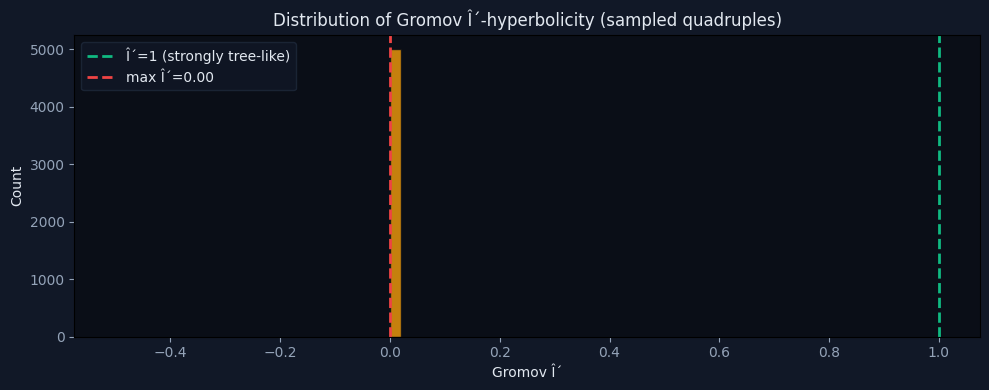

In [11]:
# Distribution of Î´ values
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(delta_samples, bins=50, color='#f59e0b', alpha=0.8, edgecolor='#0a0e17')
ax.axvline(x=1.0, color='#10b981', linestyle='--', linewidth=2, label='Î´=1 (strongly tree-like)')
ax.axvline(x=max_delta, color='#ef4444', linestyle='--', linewidth=2, label=f'max Î´={max_delta:.2f}')
ax.set_xlabel('Gromov Î´', color='#e2e8f0')
ax.set_ylabel('Count', color='#e2e8f0')
ax.set_title('Distribution of Gromov Î´-hyperbolicity (sampled quadruples)', color='#e2e8f0')
ax.set_facecolor('#0a0e17')
ax.tick_params(colors='#94a3b8')
ax.legend(facecolor='#111827', edgecolor='#1e293b', labelcolor='#e2e8f0')
fig.patch.set_facecolor('#111827')
plt.tight_layout()
plt.show()

## 6. Connected Components & Diameter

In [12]:
# Connected component analysis
components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in components], reverse=True)

print(f"=== CONNECTED COMPONENTS ===")
print(f"  Total components:  {len(components)}")
print(f"  Largest:           {component_sizes[0]:,} nodes")
if len(component_sizes) > 1:
    print(f"  2nd largest:       {component_sizes[1]:,} nodes")
print(f"  Singletons:        {sum(1 for s in component_sizes if s == 1)}")

# Diameter of largest component (approximate for large graphs)
if G.number_of_nodes() < 5000:
    diameter = nx.diameter(G)
    print(f"\n  Graph diameter:    {diameter}")
    print(f"  (large diameter relative to log(n)={np.log(G.number_of_nodes()):.1f} â†’ tree-like)")
else:
    # Approximate via BFS from random nodes
    approx_diameters = []
    for _ in range(20):
        start = np.random.choice(list(G.nodes()))
        lengths = nx.single_source_shortest_path_length(G, start)
        approx_diameters.append(max(lengths.values()))
    print(f"\n  Approx diameter:   {max(approx_diameters)} (from 20 random BFS)")
    print(f"  log(n):            {np.log(G.number_of_nodes()):.1f}")
    print(f"  (diameter >> log(n) â†’ tree-like structure)")

=== CONNECTED COMPONENTS ===
  Total components:  1
  Largest:           300 nodes
  Singletons:        0

  Graph diameter:    9
  (large diameter relative to log(n)=5.7 â†’ tree-like)


## 7. Edge Type Analysis
How heterogeneous is the graph? This determines how much edge-typed attention can help.

In [13]:
# Edge type co-occurrence: which node types connect via which edge types?
edge_patterns = run_query("""
    MATCH (a)-[r]->(b)
    RETURN 
        labels(a)[0] AS source_type,
        type(r) AS rel_type,
        labels(b)[0] AS target_type,
        count(*) AS count
    ORDER BY count DESC
    LIMIT 30
""")

print("=== EDGE TYPE PATTERNS (top 30) ===")
print(f"  {'Source':20s} --{'Relationship':25s}--> {'Target':20s}  {'Count':>10s}")
print("  " + "-" * 85)
for row in edge_patterns:
    print(f"  {row['source_type']:20s} --{row['rel_type']:25s}--> {row['target_type']:20s}  {row['count']:>10,}")

n_edge_types = len(set(r['rel_type'] for r in edge_patterns))
n_patterns = len(edge_patterns)
print(f"\n  Distinct edge types: {n_edge_types}")
print(f"  Distinct patterns:   {n_patterns}")
print(f"  (More types + more patterns â†’ stronger case for edge-typed attention)")

=== EDGE TYPE PATTERNS (top 30) ===
  Source               --Relationship             --> Target                     Count
  -------------------------------------------------------------------------------------
  Paragraph            --CONTAINS_MENTION         --> Mention                  130,205
  Paragraph            --HAS_CLAIM                --> Claim                     45,793
  Claim                --EVIDENCED_BY             --> Paragraph                 45,793
  ExtractionRun        --PRODUCED                 --> Claim                     45,793
  Claim                --OCCURRED_DURING          --> Period                    37,046
  Claim                --TRIGGERED                --> Event                     35,729
  Event                --SOURCED_FROM             --> Paragraph                 35,729
  Event                --IN_YEAR                  --> Year                      35,621
  Section              --HAS_PARAGRAPH            --> Paragraph                 30,768
  Even

## 8. Summary & Decision

In [14]:
print("="*60)
print("  GRAPH PROPERTY SUMMARY")
print("="*60)
print(f"")
print(f"  Nodes:             {total_nodes:,}")
print(f"  Edges:             {total_edges:,}")
print(f"  Edge/Node ratio:   {total_edges/total_nodes:.2f}")
print(f"  Edge types:        {n_edge_types}")
print(f"  Mean degree:       {np.mean(degrees):.2f}")
print(f"  Median degree:     {np.median(degrees):.1f}")
print(f"  Gromov Î´ (approx): {max_delta:.2f}")
print(f"")
print("  ARCHITECTURAL IMPLICATIONS:")
print(f"")

# Automated decision logic
hyperbolic_score = 0
reasons = []

if total_edges / total_nodes < 3.0:
    hyperbolic_score += 1
    reasons.append("  âœ“ Low edge/node ratio â†’ sparse, tree-like")
else:
    reasons.append("  âœ— High edge/node ratio â†’ dense graph")

if np.median(degrees) <= 3:
    hyperbolic_score += 1
    reasons.append("  âœ“ Low median degree â†’ most nodes are leaves")
else:
    reasons.append("  âœ— High median degree â†’ not leaf-heavy")

if max_delta < 2.0:
    hyperbolic_score += 2
    reasons.append("  âœ“ Low Gromov Î´ â†’ strongly tree-like (major signal)")
elif max_delta < 4.0:
    hyperbolic_score += 1
    reasons.append("  ~ Moderate Gromov Î´ â†’ somewhat tree-like")
else:
    reasons.append("  âœ— High Gromov Î´ â†’ not tree-like")

if n_edge_types >= 3:
    reasons.append(f"  âœ“ {n_edge_types} edge types â†’ heterogeneous attention justified")
else:
    reasons.append(f"  ~ Only {n_edge_types} edge types â†’ limited heterogeneity")

for r in reasons:
    print(r)

print(f"")
print(f"  HYPERBOLIC GEOMETRY SCORE: {hyperbolic_score}/4")
if hyperbolic_score >= 3:
    print("  â†’ STRONGLY JUSTIFIED. Proceed with PoincarÃ© ball embeddings.")
elif hyperbolic_score >= 2:
    print("  â†’ JUSTIFIED. Hyperbolic likely helps, worth testing.")
elif hyperbolic_score >= 1:
    print("  â†’ UNCERTAIN. Run both Euclidean and hyperbolic, compare empirically.")
else:
    print("  â†’ NOT JUSTIFIED. Consider Euclidean geometry or mixed-curvature approach.")

print(f"")
print("  Save these numbers. They constrain every architectural decision downstream.")
print("="*60)

  GRAPH PROPERTY SUMMARY

  Nodes:             300,706
  Edges:             685,606
  Edge/Node ratio:   2.28
  Edge types:        22
  Mean degree:       4.64
  Median degree:     2.0
  Gromov Î´ (approx): 0.00

  ARCHITECTURAL IMPLICATIONS:

  âœ“ Low edge/node ratio â†’ sparse, tree-like
  âœ“ Low median degree â†’ most nodes are leaves
  âœ“ Low Gromov Î´ â†’ strongly tree-like (major signal)
  âœ“ 22 edge types â†’ heterogeneous attention justified

  HYPERBOLIC GEOMETRY SCORE: 4/4
  â†’ STRONGLY JUSTIFIED. Proceed with PoincarÃ© ball embeddings.

  Save these numbers. They constrain every architectural decision downstream.


In [15]:
# Cleanup
driver.close()
print("Neo4j connection closed.")

Neo4j connection closed.
